# Finetunning de Stable Diffusion para Portadas de Libros Antiguos
## Máster en Inteligencia Artificial, Cloud Computing y DevOps
## Módulo: Generacion de Imagenes con AI
## Autor: Alexander De Sousa

Este notebook documenta el proceso completo de finetuning de un modelo de difusión (Stable Diffusion 1.5) utilizando un dataset de ilustraciones y portadas de libros antiguos.  
El objetivo es adaptar el modelo base para que aprenda el estilo visual característico de este tipo de obras, generando imágenes coherentes, estilizadas y reproducibles.

El trabajo incluye:

- Preparación y preprocesamiento del dataset.
- Entrenamiento completo del modelo (UNet) y entrenamiento mediante LoRA.
- Comparación entre resultados antes y después del finetuning.
- Evaluación cualitativa del estilo aprendido.
- Publicación del modelo en Hugging Face para su reutilización.

Este documento constituye la entrega final del módulo de Generación de Imágenes con IA.
---


#### 1. Instalación de dependencias
Instalamos las librerías necesarias para trabajar con Stable Diffusion, datasets y entrenamiento acelerado.

In [1]:
!pip install -q "diffusers[torch]" "datasets>=2.16,<2.17" accelerate transformers pillow huggingface_hub


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


#### 2. Imports
Cargamos todas las clases y funciones que vamos a usar en el proyecto.

In [2]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

from datasets import load_dataset
from diffusers import (
    UNet2DConditionModel,
    AutoencoderKL,
    DDPMScheduler,
    StableDiffusionPipeline,
)
from transformers import CLIPTextModel, CLIPTokenizer
from accelerate import Accelerator
from huggingface_hub import upload_folder



#### 3. Configuración de dispositivo
Detectamos si hay GPU disponible en el equipo, en caso de que no exista se entrenara Stable Diffusion con la CPU, pero es extremadamente lento.

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo detectado:", device)

Dispositivo detectado: cuda


*Información detallada de la GPU a usar*

In [4]:
if device == "cuda":
    !nvidia-smi

Tue Jun 16 22:10:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.47        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   59C    P0             29W /  140W |    2487MiB /   8192MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### 4. Cargar dataset nuevo
Cargamos el dataset gigant/oldbookillustrations, que contiene ilustraciones antiguas de libros.

In [5]:
# Nombre del modelo base (Stable Diffusion 1.4)
pretrained_model_name = "CompVis/stable-diffusion-v1-4"

# Dataset de ilustraciones de libros antiguos
dataset_name = "gigant/oldbookillustrations"

# Limitamos el número de muestras para que el entrenamiento no dure 6+ horas
max_train_samples = 100

dataset = load_dataset(dataset_name, split="train")
if max_train_samples:
    dataset = dataset.select(range(max_train_samples))

print("Ejemplo de claves del dataset:", dataset[0].keys())

Ejemplo de claves del dataset: dict_keys(['rawscan', '1600px', 'info_url', 'info_src', 'info_alt', 'artist_name', 'artist_birth_date', 'artist_death_date', 'artist_countries', 'book_title', 'book_authors', 'book_publishers', 'date_published', 'openlibrary-url', 'tags', 'illustration_source_name', 'illustration_source_url', 'illustration_subject', 'illustration_format', 'engravers', 'image_title', 'image_caption', 'image_description', 'rawscan_url', '1600px_url'])


#### 5. Transformaciones (imágenes no cuadradas)
Convertimos las imágenes a un formato que Stable Diffusion pueda usar.

In [6]:
resolution = 256

image_transforms = transforms.Compose([
    transforms.Resize(resolution),
    transforms.CenterCrop((resolution, resolution)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


#### 6. Tokenizer
Cargamos el tokenizer de CLIP, que convierte texto en tokens numéricos.

In [7]:
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name, subfolder="tokenizer")

#### 7. Dataset wrapper adaptado


In [8]:
class OldBookDataset(Dataset):
    """
    Dataset para el finetuning:
    - Usa la columna '1600px' como imagen
    - Usa la columna 'info_alt' como descripción
    - Convierte todas las imágenes a RGB (aunque algunas sean B/N)
    """

    def __init__(self, hf_dataset, tokenizer, image_transforms):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]

        # Imagen: columna '1600px', convertida a RGB
        image: Image.Image = example["1600px"].convert("RGB")
        image = self.image_transforms(image)

        # Texto: columna 'info_alt'
        text = example["info_alt"]

        tokens = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        )

        return {
            "pixel_values": image,
            "input_ids": tokens.input_ids.squeeze(0),
            "attention_mask": tokens.attention_mask.squeeze(0),
        }

train_dataset = OldBookDataset(dataset, tokenizer, image_transforms)
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True)
len(train_dataset), next(iter(train_dataloader))["pixel_values"].shape


(100, torch.Size([2, 3, 256, 256]))

#### 8. Cargar componentes del modelo base

In [9]:
# Liberamos memoria de GPU por si venimos de ejecuciones anteriores
if device == "cuda":
    torch.cuda.empty_cache()

# Scheduler de difusión
noise_scheduler = DDPMScheduler.from_pretrained(pretrained_model_name, subfolder="scheduler")

# Text encoder CLIP
text_encoder = CLIPTextModel.from_pretrained(
    pretrained_model_name,
    subfolder="text_encoder"
).to(device)

# VAE (Autoencoder)
vae = AutoencoderKL.from_pretrained(
    pretrained_model_name,
    subfolder="vae"
).to(device)

# UNet (la parte que vamos a finetunear)
unet = UNet2DConditionModel.from_pretrained(
    pretrained_model_name,
    subfolder="unet"
).to(device)

/home/alexd/GitHub/entrega_final_modelo_gi/env-diffusers2/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

#### 9. Congelar VAE y Text Encoder (Transfer learning)
No queremos entrenar VAE ni text encoder, solo la UNet

In [10]:
vae.eval()
text_encoder.eval()

for p in vae.parameters():
    p.requires_grad = False

for p in text_encoder.parameters():
    p.requires_grad = False

#### 10. Preparar entrenamiento
En este caso el num_epochs lo ajustamos a 2, tal cual como lo sugiere el enunciado del ejercicio.

In [11]:
learning_rate = 1e-5
num_epochs = 2          # (puedes aumentar cuando veas que la velocidad es aceptable)

optimizer = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

  # Mixed precision solo si estamos en CUDA
accelerator = Accelerator(
    mixed_precision="fp16" if device == "cuda" else "no",
    gradient_accumulation_steps=1   # aumenta a 2‑4 si la GPU se queda sin VRAM
)

  # Preparar los objetos (mueve todo a la GPU si corresponde)
unet, optimizer, train_dataloader = accelerator.prepare(unet, optimizer, train_dataloader)

  # Aseguramos que VAE y Text Encoder también estén en la GPU
if device == "cuda":
    vae.to(device)
    text_encoder.to(device)

print(f"⚙️   Device: {device}")
print(f"🚀  Accelerator mixed precision: {accelerator.state.mixed_precision}")

  # Verificamos que los tensores del DataLoader están en el device correcto
sample_batch = next(iter(train_dataloader))
print("🔎  Sample batch - pixel_values device:", sample_batch["pixel_values"].device)
print("🔎  Sample batch - input_ids device:", sample_batch["input_ids"].device)

⚙️   Device: cuda
🚀  Accelerator mixed precision: fp16
🔎  Sample batch - pixel_values device: cuda:0
🔎  Sample batch - input_ids device: cuda:0


In [12]:
learning_rate = 1e-5
num_epochs = 2

optimizer = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

accelerator = Accelerator()
unet, optimizer, train_dataloader = accelerator.prepare(unet, optimizer, train_dataloader)

text_encoder.to(accelerator.device)
vae.to(accelerator.device)

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

#### 11. Bucle de entrenamiento (finetuning)
En esta seccion la UNet aprende a generar imágenes del estilo del dataset.

In [12]:
  # -------------------------------------------------
  # 11. Bucle de entrenamiento (versión final)
  # -------------------------------------------------
unet.train()

for epoch in range(num_epochs):
      # tqdm mostrará el progreso de cada época
    progress_bar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch + 1}/{num_epochs}",
        leave=True,
    )

    for batch in progress_bar:
          # -------------------------------------------------
          # 1) Encode images → latents (sin gradientes)
          # -------------------------------------------------
        with torch.no_grad():
              # (pixel values ya están en float32)
            pixel_values = batch["pixel_values"].to(accelerator.device)

              # VAE siempre trabaja en float32 → NO lo convertimos a half
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * 0.18215   # escala estándar de Stable Diffusion

          # -------------------------------------------------
          # 2) Añadir ruido a los latentes (también float32)
          # -------------------------------------------------
        noise = torch.randn_like(latents)   # mismo dtype que latents
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],),
            device=latents.device,
        ).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

          # -------------------------------------------------
          # 3) Codificar texto
          # -------------------------------------------------
        input_ids = batch["input_ids"].to(accelerator.device)
        encoder_hidden_states = text_encoder(input_ids)[0]

          # -------------------------------------------------
          # 4) Predicción del ruido por la UNet
          # -------------------------------------------------
          # En modo fp16, `accelerator` ya habrá casteado
          # `noisy_latents` y `encoder_hidden_states` a half antes
          # de pasar a la UNet.
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

          # -------------------------------------------------
          # 5) Cálculo de la pérdida (MSE) → siempre float32
          # -------------------------------------------------
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

          # -------------------------------------------------
          # 6) Back‑prop + actualización del optimizador
          # -------------------------------------------------
        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

          # Mostrar pérdida en la barra de progreso
        progress_bar.set_postfix(loss=loss.item())

Epoch 1/2:   4%|▍         | 2/50 [1:29:57<35:58:57, 2698.70s/it, loss=0.163]


KeyboardInterrupt: 

In [ ]:
unet.train()

for epoch in range(num_epochs):
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch}", leave=True)

    for batch in progress_bar:
        # 1. Pasamos imágenes por el VAE para obtener latentes
        with torch.no_grad():
            pixel_values = batch["pixel_values"].to(accelerator.device)
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * 0.18215  # escala estándar de SD

        # 2. Añadimos ruido a los latentes
        noise = torch.randn_like(latents)
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],),
            device=latents.device,
        ).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # 3. Codificamos el texto
        input_ids = batch["input_ids"].to(accelerator.device)
        encoder_hidden_states = text_encoder(input_ids)[0]

        # 4. Predicción del ruido por la UNet
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # 5. Cálculo de la pérdida (MSE entre ruido real y predicho)
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.set_postfix(loss=loss.item())


#### 12. Guardar el modelo UNet finetuneado
Guardamos la UNet finetuneada en una carpeta de nuestro equipo.

In [ ]:
save_path = "./sd-oldbook-finetuned-unet-256-100"
os.makedirs(save_path, exist_ok=True)

unet.save_pretrained(save_path)
print("UNet finetuneada guardada en:", save_path)

UNet finetuneada guardada en: ./sd-oldbook-finetuned-unet


#### 13. Cuantización ligera para inferencia (FP16)
Nota: esto es para uso en inferencia, no reentrenes en FP16 si tu entorno no está preparado.

In [15]:
# Cargamos la UNet finetuneada en FP16 para inferencia más ligera
unet_fp16 = UNet2DConditionModel.from_pretrained(
    save_path,
    torch_dtype=torch.float16
).to(device)

# También podemos usar el pipeline completo con dtype float16
pipe_finetuned = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    unet=unet_fp16,
    torch_dtype=torch.float16
).to(device)

print("Pipeline finetuneado cargado en FP16 para inferencia.")


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Pipeline finetuneado cargado en FP16 para inferencia.


#### 14. Subir la UNet finuteado a Hugging Face
Subimos la carpeta del modelo finetuneado a nuestro repositorio personal, ubicado en *https://huggingface.co/*

In [ ]:
repo_id = "alexdesousa/sd-oldbook-finetuned-256-100"

upload_folder(
    folder_path=save_path,
    repo_id=repo_id,
    repo_type="model"
)

print("Modelo UNet finetuneado subido correctamente a Hugging Face:", repo_id)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Modelo UNet finetuneado subido correctamente a Hugging Face: alexdesousa/sd-oldbook-finetuned


#### 15. Generar imágenes antes/después

***Antes del finetuning:***  
Generamos una imagen con el modelo original.

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

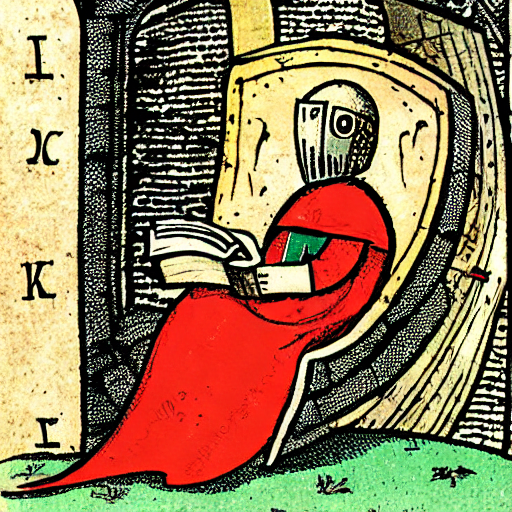

In [ ]:
pipe_base = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

prompt = "an illustration of a medieval knight reading a book"

image_before = pipe_base(prompt).images[0]
image_before.save("modelo_Original-256-100.png")
image_before


***Después del finetuning:***  
Generamos la misma imagen con el modelo finetuneado.

  0%|          | 0/50 [00:00<?, ?it/s]

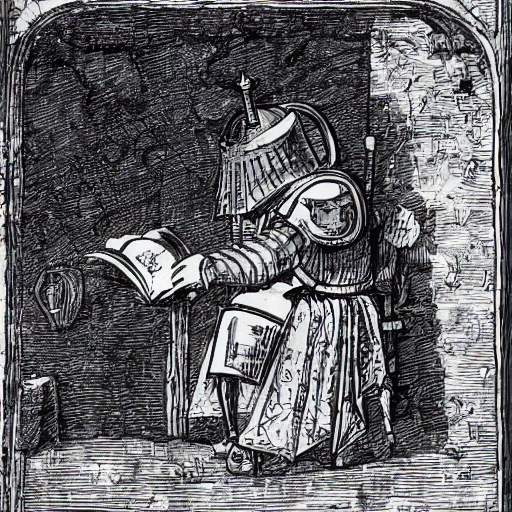

In [ ]:
image_after = pipe_finetuned(prompt).images[0]
image_after.save("modelo_Modificado-256-100.png")
image_after
